# 09 — Query Feature Ablation (Sweep C)

Staged ablation, Sweep C. Ablates query node geometry features — surface
normal (3-vector) and mean curvature (scalar, log1p-scaled), injected via
`QueryEncoder` before AQ message passing — against a zeroed-features
baseline. Baseline config inherited from Sweeps A/B: EMA + protein-weighted
loss, 4/4/4 rounds, pearson_weight=0.5, agg=multi (confirmed winner for both
architectures in Sweep B).

Re-run from scratch under the new baseline (not carried forward) since the
loss function changed — the old "features hurt" result predates EMA/weighting
and wasn't guaranteed to hold. It mostly didn't: see Section 3.

## Selection methodology

Winners chosen from validation Pearson r (`metrics.csv`, epoch of min val
loss), RMSE as tie-break, and the per-bin delta (Section 3) — not aggregate
test means alone. Test metrics are a sanity check only.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("../..").resolve()))


def show_png_grid(runs, filename, title, ncols=2):
    """Display saved PNG plots from each run's plot_dir in a grid.

    analyze_model.py saves plots with a model-name prefix (e.g.
    'attention_parity_hexbin.png'), so the actual filename is built per-run
    from run['model_type'] — passing a bare 'parity_hexbin.png' here is
    deliberate, the prefix is added below.
    """
    def _path(run):
        return run["plot_dir"] / f"{run['model_type']}_{filename}"

    available = [r for r in runs if _path(r).exists()]
    if not available:
        print(f"No '*_{filename}' plots found. Run analyze_model.py --save-plots first.")
        return
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    for ax, run in zip(axes, available):
        ax.imshow(mpimg.imread(_path(run)))
        ax.set_title(run["label"], fontsize=11)
        ax.axis("off")
    for ax in axes[len(available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_metric_bars(df, title_prefix, metrics, x_col="Features"):
    """1-row x 2-col grouped bar chart: one chart per model type."""
    if df.empty:
        print("No data to plot.")
        return
    model_types = ["Attention", "Distance"]
    fig, axes = plt.subplots(1, len(model_types), figsize=(14, 5), sharey=False)
    fig.suptitle(title_prefix, fontsize=13, fontweight="bold")
    n_metrics = len(metrics)
    total_width = 0.7
    bar_w = total_width / n_metrics
    for ax, model_type in zip(axes, model_types):
        sub = df[df["Model"] == model_type].copy()
        if sub.empty:
            ax.set_visible(False)
            continue
        x = range(len(sub))
        for i, (metric, color) in enumerate(metrics):
            if metric not in sub.columns or sub[metric].isna().all():
                continue
            offsets = [xi - total_width / 2 + bar_w * i + bar_w / 2 for xi in x]
            bars = ax.bar(offsets, sub[metric], width=bar_w, color=color, label=metric, zorder=3)
            ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8, rotation=90)
        ax.set_title(model_type, fontsize=12)
        ax.set_xlabel(x_col)
        ax.set_xticks(list(x))
        ax.set_xticklabels(sub[x_col].tolist(), fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()

## 1. Configuration

In [2]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints"
EVAL_ROOT   = THESIS_ROOT / "model_eval"

RUNS = [
    dict(label="Attention — features off (baseline)", model_type="attention", features="off",
         plot_dir=EVAL_ROOT / "phase_a" / "attention_pw05",
         ckpt_dir=CKPT_ROOT / "phase_a" / "attention_pw05"),
    dict(label="Distance — features off (baseline)",  model_type="distance",  features="off",
         plot_dir=EVAL_ROOT / "phase_a" / "distance_pw05",
         ckpt_dir=CKPT_ROOT / "phase_a" / "distance_pw05"),
    dict(label="Attention — features on",  model_type="attention", features="on",
         plot_dir=EVAL_ROOT / "phase_c" / "attention_on",
         ckpt_dir=CKPT_ROOT / "phase_c" / "attention_on"),
    dict(label="Distance — features on",   model_type="distance",  features="on",
         plot_dir=EVAL_ROOT / "phase_c" / "distance_on",
         ckpt_dir=CKPT_ROOT / "phase_c" / "distance_on"),
]

print(f"{'Run':<34}  {'Plots':>6}  {'Metrics':>8}")
print("-" * 54)
for r in RUNS:
    has_plots   = r["plot_dir"].exists()
    has_metrics = (r["ckpt_dir"] / "metrics.csv").exists()
    print(f"{r['label']:<34}  {'yes' if has_plots else 'no':>6}  {'yes' if has_metrics else 'no':>8}")

Run                                  Plots   Metrics
------------------------------------------------------
Attention — features off (baseline)     yes       yes
Distance — features off (baseline)     yes       yes
Attention — features on                yes       yes
Distance — features on                 yes       yes


## 2. Hexbin + Sorted Predictions

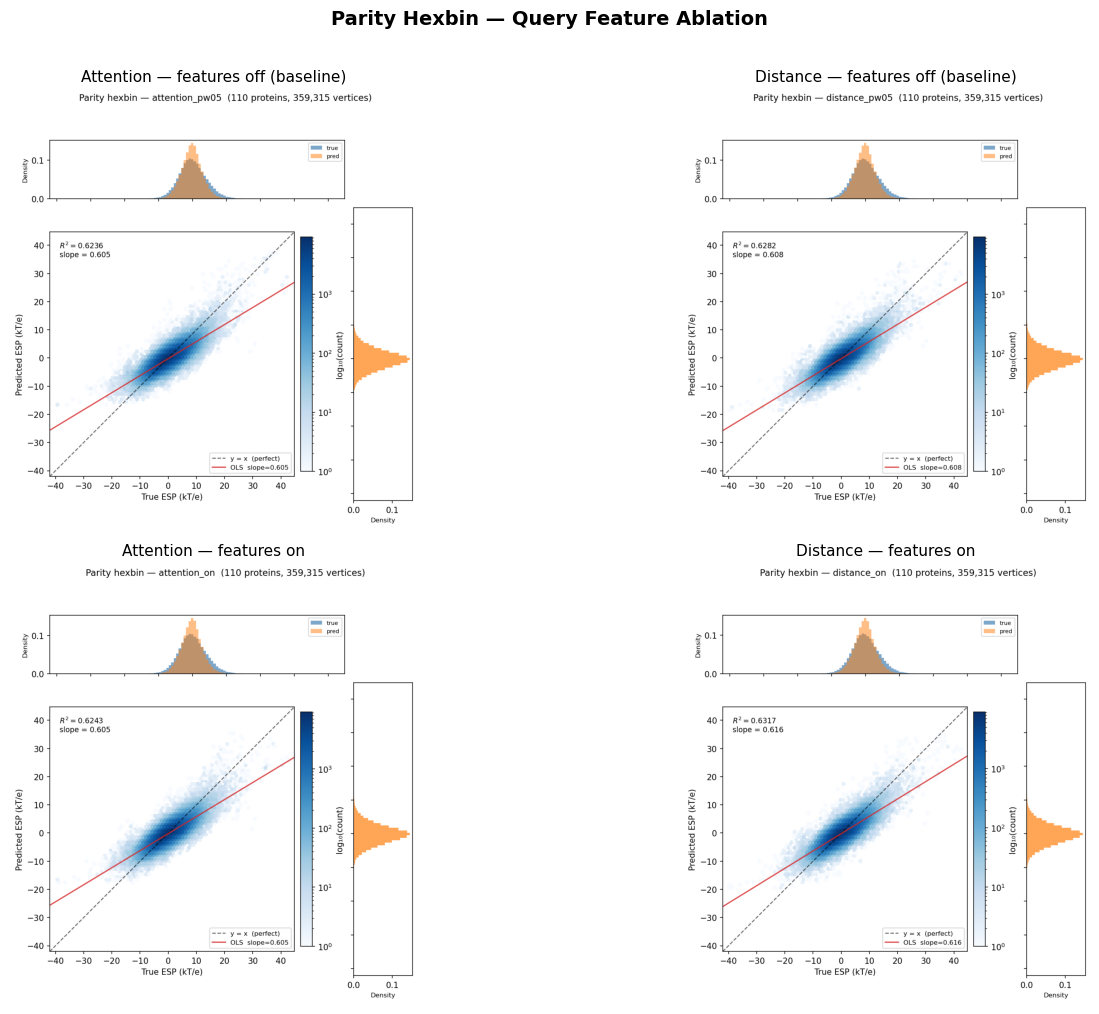

In [3]:
show_png_grid(RUNS, "parity_hexbin.png", "Parity Hexbin — Query Feature Ablation")

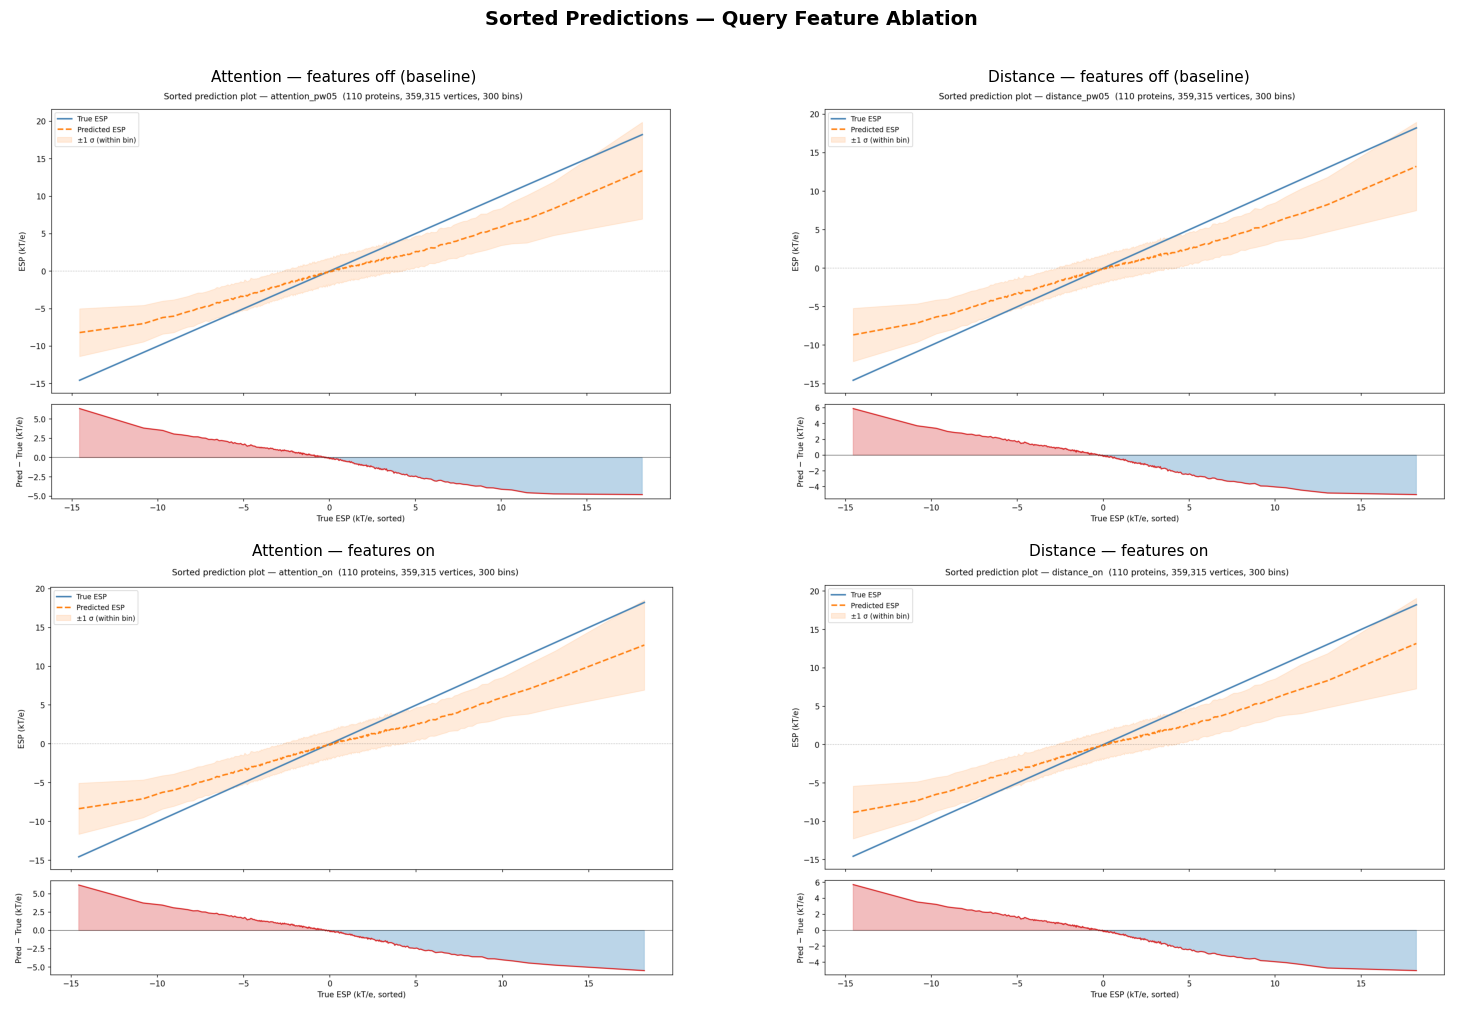

In [4]:
show_png_grid(RUNS, "sorted_predictions.png", "Sorted Predictions — Query Feature Ablation")

## 3. Per-Bin Comparison vs Baseline (features off)

Generated with, for each model:

```bash
python scripts/analyze_model.py --checkpoint-dir checkpoints/phase_c/<model>_on \
    --delta-vs checkpoints/phase_a/<model>_pw05 --model <model> --save-plots model_eval/phase_c/<model>_on
```

Positive (blue) bars = `on` beats `off` in that ESP bin.

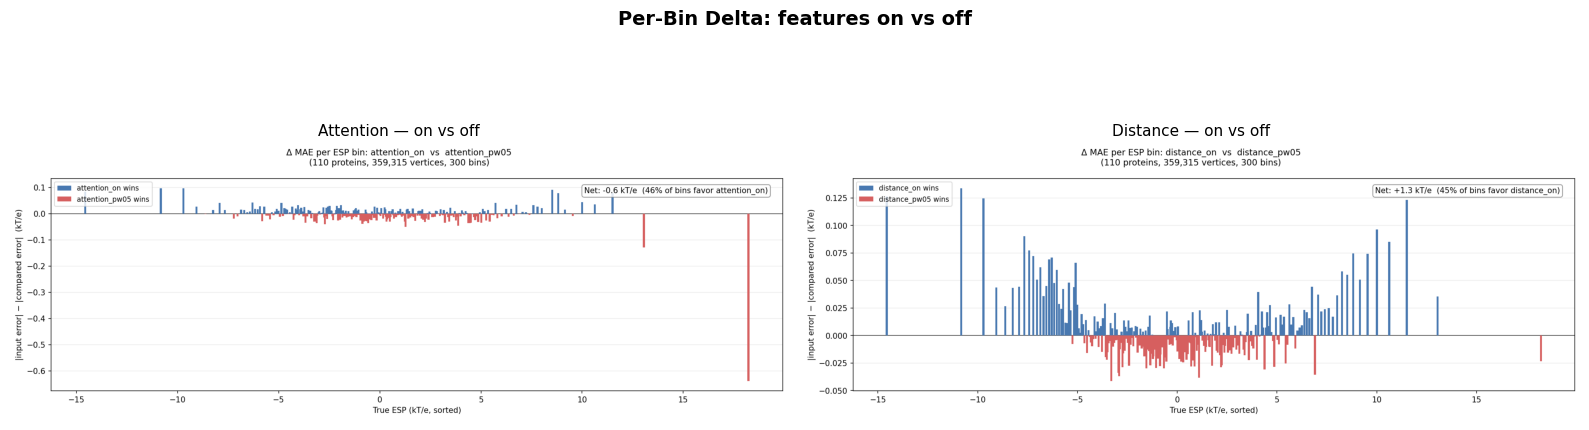


Range breakdown (on vs off), by true-ESP band:


,Comparison,range,n_bins,net_delta_kT_e,mean_delta_kT_e,pct_bins_favor_compared
0,Attention on vs off,"[-15, -8)",6,-3.703,-0.617,0.000
1,Attention on vs off,"[-8, -2)",86,-7.535,-0.088,32.558
2,Attention on vs off,"[-2, 2)",118,13.883,0.118,100.000
3,Attention on vs off,"[2, 8)",79,13.305,0.168,100.000
4,Attention on vs off,"[8, 15)",10,2.205,0.221,100.000
5,Distance on vs off,"[-15, -8)",6,0.498,0.083,100.000
6,Distance on vs off,"[-8, -2)",86,0.903,0.010,59.302
7,Distance on vs off,"[-2, 2)",118,-0.901,-0.008,25.424
8,Distance on vs off,"[2, 8)",79,0.088,0.001,49.367
9,Distance on vs off,"[8, 15)",10,0.690,0.069,100.000


In [5]:
from src.analysis.model_plots import range_delta_breakdown

delta_items = [
    dict(label=f"{model.capitalize()} — on vs off",
         path=EVAL_ROOT/"phase_c"/f"{model}_on"/f"{model}_delta_vs_{model}_pw05.png")
    for model in ["attention", "distance"]
]
show_png_grid_paths = [it for it in delta_items if it["path"].exists()]
if not show_png_grid_paths:
    print("No delta plots found yet.")
else:
    nrows = (len(show_png_grid_paths) + 1) // 2
    fig, axes = plt.subplots(nrows, 2, figsize=(16, 5 * nrows))
    axes = axes.flatten() if nrows * 2 > 1 else [axes]
    fig.suptitle("Per-Bin Delta: features on vs off", fontsize=14, fontweight="bold", y=1.01)
    for ax, it in zip(axes, show_png_grid_paths):
        ax.imshow(mpimg.imread(it["path"]))
        ax.set_title(it["label"], fontsize=11)
        ax.axis("off")
    for ax in axes[len(show_png_grid_paths):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

print("\nRange breakdown (on vs off), by true-ESP band:")
frames = []
for model in ["attention", "distance"]:
    ckpt_off = CKPT_ROOT / "phase_a" / f"{model}_pw05"
    ckpt_on  = CKPT_ROOT / "phase_c" / f"{model}_on"
    if not (ckpt_off / "test_predictions").exists() or not (ckpt_on / "test_predictions").exists():
        continue
    df = range_delta_breakdown(ckpt_off, ckpt_on)
    if df is None:
        continue
    df.insert(0, "Comparison", f"{model.capitalize()} on vs off")
    frames.append(df)

if frames:
    pd.set_option("display.float_format", "{:.3f}".format)
    display(pd.concat(frames, ignore_index=True))
else:
    print("No test_predictions/ found yet for one or both runs.")

## 4. Training Curves

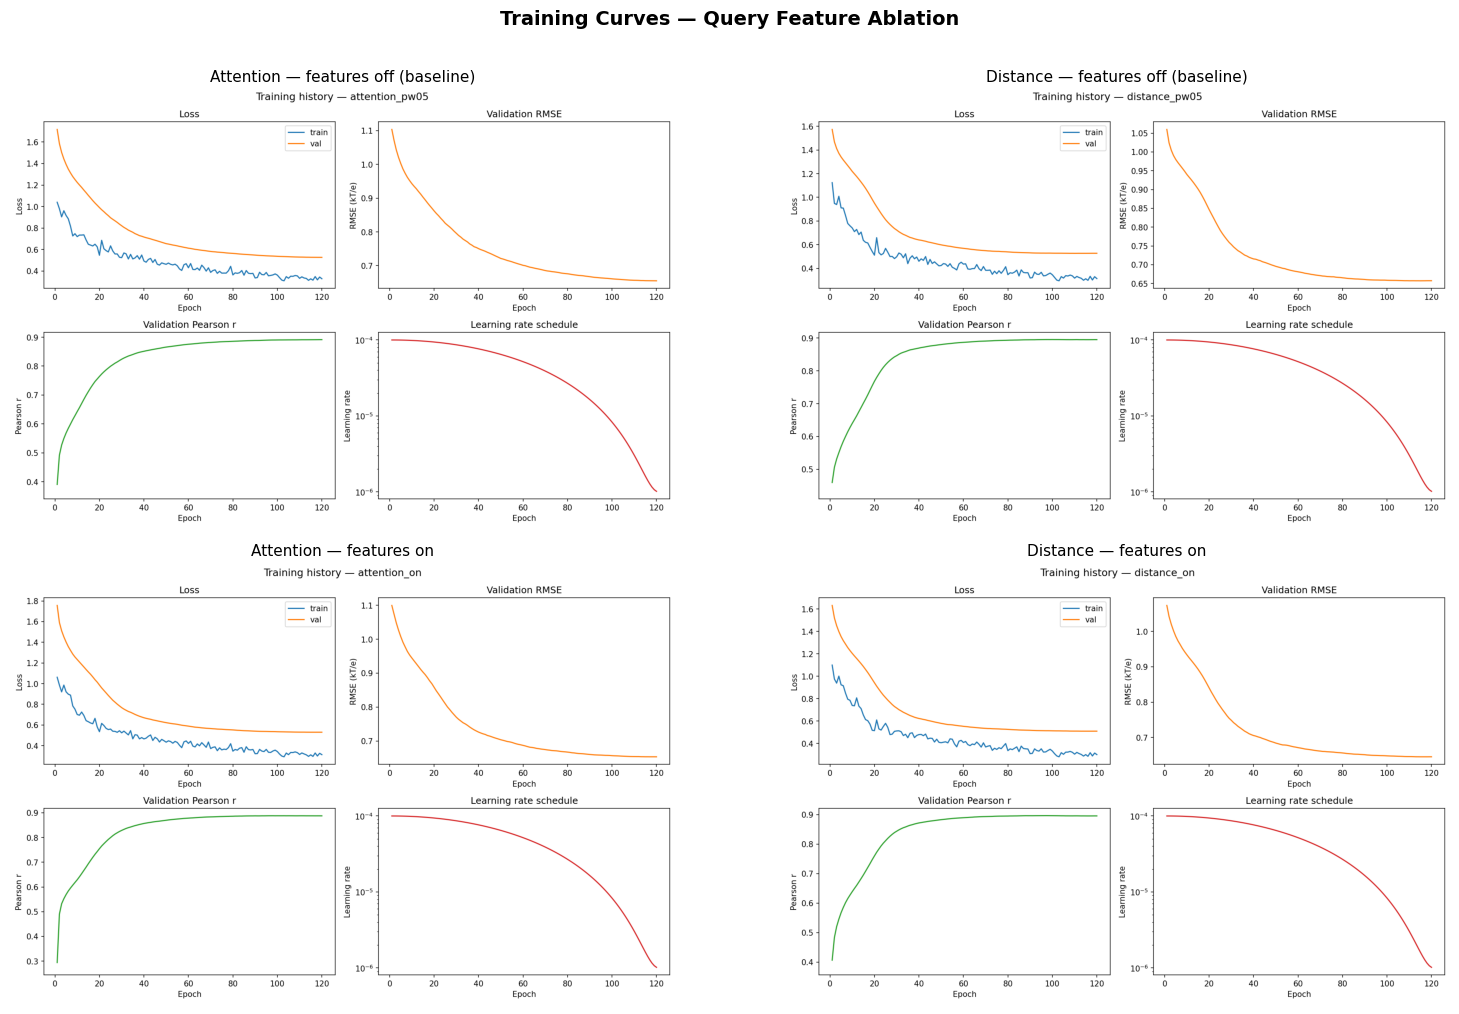

In [6]:
show_png_grid(RUNS, "training_curves.png", "Training Curves — Query Feature Ablation")

## 5. Validation Metrics Comparison (selection basis)

,Run,Model,Features,Pearson r,RMSE,Val loss,Train loss,Train/val gap,Best epoch
0,Attention — features off (baseline),Attention,off,0.8915,0.6551,0.5270,0.3283,-0.1987,120
2,Attention — features on,Attention,on,0.8876,0.6532,0.5299,0.3289,-0.2009,117
3,Distance — features on,Distance,on,0.8956,0.6454,0.5093,0.2999,-0.2093,115
1,Distance — features off (baseline),Distance,off,0.8953,0.6573,0.5273,0.3179,-0.2093,110


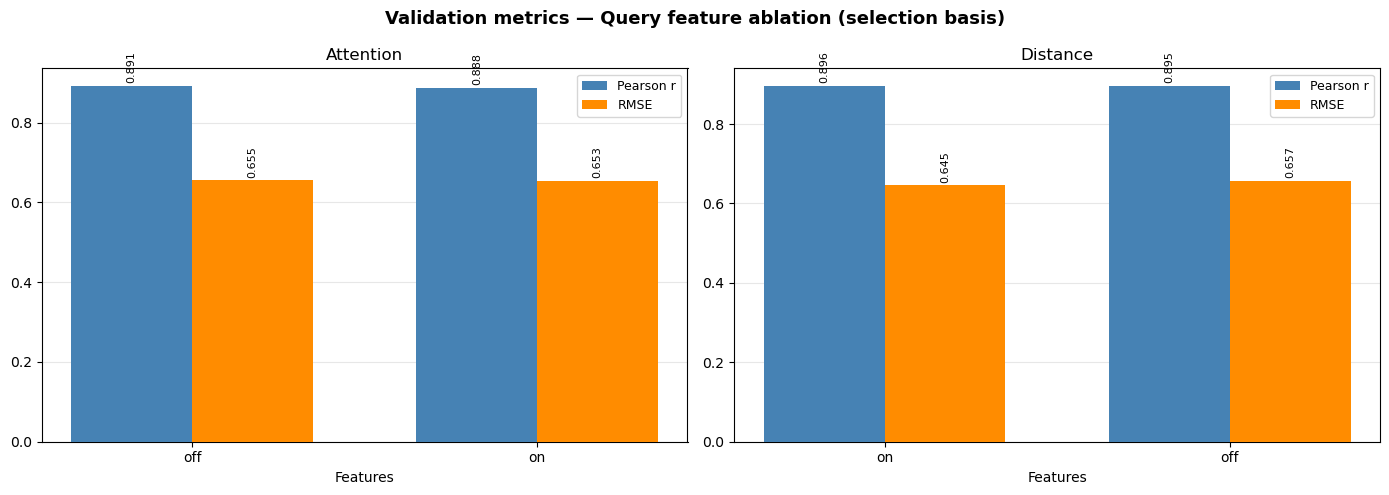

In [7]:
rows = []
for run in RUNS:
    csv_path = run["ckpt_dir"] / "metrics.csv"
    if not csv_path.exists():
        continue
    hist = pd.read_csv(csv_path)
    if hist.empty:
        continue
    best = hist.loc[hist["val_loss"].idxmin()]
    rows.append({
        "Run":           run["label"],
        "Model":         run["model_type"].capitalize(),
        "Features":      run["features"],
        "Pearson r":     best["val_pearson_r"],
        "RMSE":          best["val_rmse"],
        "Val loss":      best["val_loss"],
        "Train loss":    best["train_loss"],
        "Train/val gap": best["train_loss"] - best["val_loss"],
        "Best epoch":    int(best["epoch"]),
    })

val_df = pd.DataFrame(rows).sort_values(["Model", "Pearson r"], ascending=[True, False])
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
display(val_df)
plot_metric_bars(val_df, "Validation metrics — Query feature ablation (selection basis)",
                  metrics=[("Pearson r", "steelblue"), ("RMSE", "darkorange")])

## 6. Test Metrics (reference only — not used for selection)

,Run,Model,Features,Pearson r,RMSE,MAE,Train time (s),N proteins
2,Attention — features on,Attention,on,0.8902,2.5864,1.9969,5480.5000,110
0,Attention — features off (baseline),Attention,off,0.8898,2.6598,2.0558,NaN,110
1,Distance — features off (baseline),Distance,off,0.8964,2.5730,1.9857,7082.3000,110
3,Distance — features on,Distance,on,0.8960,2.5609,1.9815,7246.8000,110


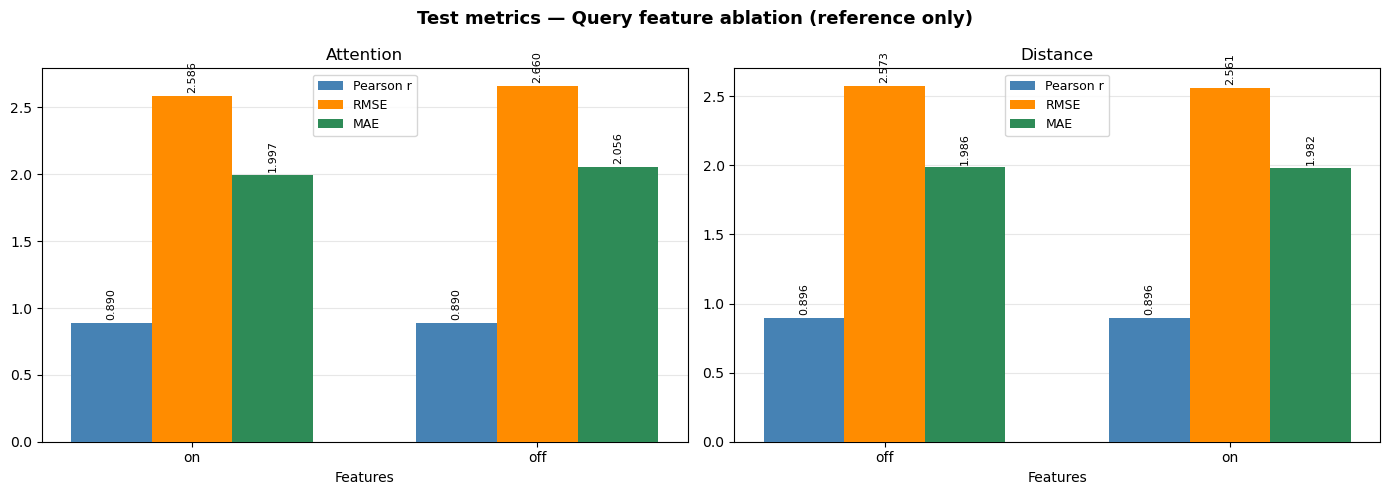

In [8]:
rows_test = []
for run in RUNS:
    metrics_path = run["ckpt_dir"] / "test_metrics.json"
    if not metrics_path.exists():
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    g = data.get("global", {})
    rows_test.append({
        "Run":            run["label"],
        "Model":          run["model_type"].capitalize(),
        "Features":       run["features"],
        "Pearson r":      g.get("pearson_r"),
        "RMSE":           g.get("rmse"),
        "MAE":            g.get("mae"),
        "Train time (s)": g.get("train_wall_time_s"),
        "N proteins":     g.get("n_proteins"),
    })

test_df = pd.DataFrame(rows_test).sort_values(["Model", "Pearson r"], ascending=[True, False])
display(test_df)
plot_metric_bars(test_df, "Test metrics — Query feature ablation (reference only)",
                  metrics=[("Pearson r", "steelblue"), ("RMSE", "darkorange"), ("MAE", "seagreen")])

## 7. Spatial Error Metrics

Computed from `test_predictions/*.npz` by `--spatial-metrics` (cached as
`test_spatial_metrics.json`).

**Key question**: does giving the model surface normals and curvature
reduce the ESP-error Spearman r? If geometry features help, we'd expect the
`features on` model to show lower ESP-error r — meaning errors are less
concentrated near high-|ESP| (geometrically complex) surface regions. A
drop in Moran's I would additionally indicate that the model is spreading
errors more evenly across the surface rather than failing in the same
patches.

,Run,Model,Features,Moran's I,Moran's I std,ESP-error r,ESP-error std,N proteins
0,Attention — features off (baseline),Attention,off,0.6933,0.1118,0.0791,0.1779,110
2,Attention — features on,Attention,on,0.6930,0.1134,0.0858,0.1743,110
1,Distance — features off (baseline),Distance,off,0.6999,0.1179,0.0706,0.1822,110
3,Distance — features on,Distance,on,0.6996,0.1137,0.0685,0.1799,110


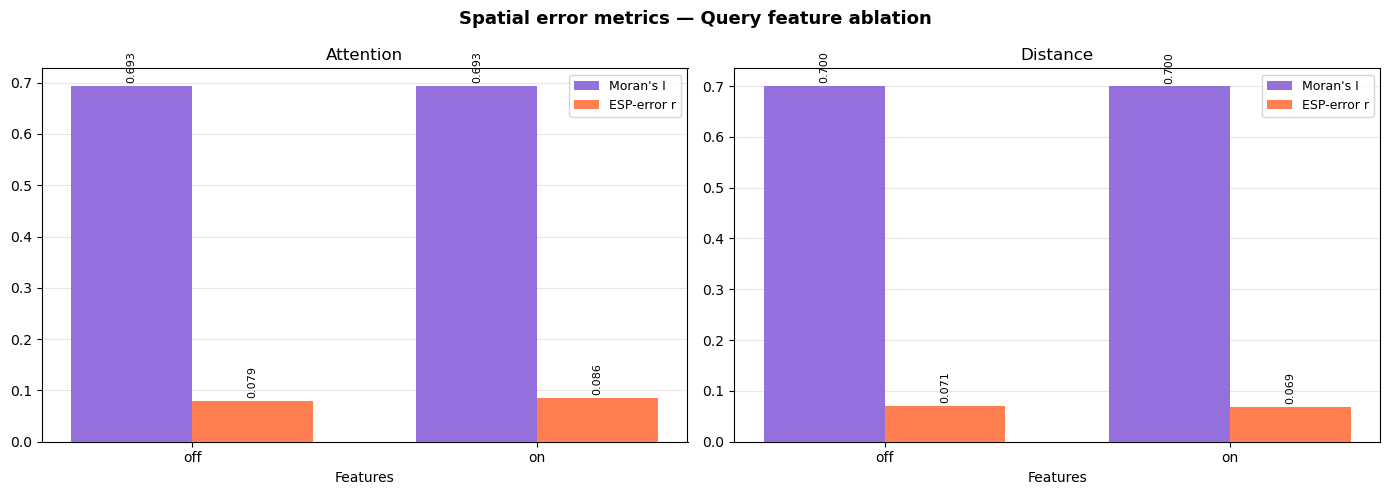

In [9]:
rows_spatial = []
for run in RUNS:
    sp_path = run["ckpt_dir"] / "test_spatial_metrics.json"
    if not sp_path.exists():
        continue
    with open(sp_path) as f:
        sp = json.load(f)
    g = sp.get("global", {})
    rows_spatial.append({
        "Run":            run["label"],
        "Model":          run["model_type"].capitalize(),
        "Features":       run["features"],
        "Moran's I":      g.get("mean_morans_i"),
        "Moran's I std":  g.get("std_morans_i"),
        "ESP-error r":    g.get("mean_esp_error_spearman"),
        "ESP-error std":  g.get("std_esp_error_spearman"),
        "N proteins":     g.get("n_proteins"),
    })

if not rows_spatial:
    print("No test_spatial_metrics.json found. Run: analyze_model.py --spatial-metrics")
else:
    spatial_df = pd.DataFrame(rows_spatial).sort_values(["Model", "Features"])
    display(spatial_df)
    plot_metric_bars(
        spatial_df,
        "Spatial error metrics — Query feature ablation",
        metrics=[("Moran's I", "mediumpurple"), ("ESP-error r", "coral")],
    )

## 8. Per-Protein Ranking

Per-protein Pearson r (from `test_metrics.json`) across all 4 runs — which
proteins are universally easy or hard, and which are feature-sensitive?

In [10]:
pp_data: dict[str, dict[str, float]] = {}

for run in RUNS:
    metrics_path = run["ckpt_dir"] / "test_metrics.json"
    if not metrics_path.exists():
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    pp = data.get("per_protein", {})
    pp_data[run["label"]] = {pid: v["pearson_r"] for pid, v in pp.items()}

all_proteins = sorted({pid for d in pp_data.values() for pid in d})
run_labels   = list(pp_data.keys())

pivot = pd.DataFrame(
    {label: [pp_data[label].get(pid, float("nan")) for pid in all_proteins]
     for label in run_labels},
    index=all_proteins,
)

def _short(pid):
    return pid.removeprefix("AF-").removesuffix("-F1")

pivot.index = [_short(p) for p in pivot.index]

pivot["_mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("_mean", ascending=False).drop(columns=["_mean"])

print(f"Loaded per-protein data for {len(pivot)} proteins across {len(run_labels)} runs.")

Loaded per-protein data for 110 proteins across 4 runs.


In [11]:
rank_df = pivot.rank(ascending=False, method="min").astype(int)

rank_df.insert(0, "Mean r",    pivot.mean(axis=1).round(4))
rank_df.insert(1, "Std r",     pivot.std(axis=1).round(4))
rank_df.insert(2, "Mean rank", rank_df.iloc[:, 2:].mean(axis=1).round(2))
rank_df.insert(3, "Rank std",  rank_df.iloc[:, 3:].std(axis=1).round(2))

rank_df = rank_df.sort_values("Mean rank")

print("Top 5 proteins (lowest mean rank = most consistently well-predicted):")
display(rank_df.head(5))

print("\nBottom 5 proteins (highest mean rank = most consistently difficult):")
display(rank_df.tail(5))

print("\nMost feature-sensitive proteins (highest rank std):")
display(rank_df.sort_values("Rank std", ascending=False).head(5))

Top 5 proteins (lowest mean rank = most consistently well-predicted):


,Mean r,Std r,Mean rank,Rank std,Attention — features off (baseline),Distance — features off (baseline),Attention — features on,Distance — features on
Q8RUD6,0.9545,0.0043,2.0000,1.1500,1,1,3,3
A1SHW4,0.9569,0.0038,2.2500,1.8900,5,2,1,1
Q9GKK3-3,0.9559,0.0019,2.2500,0.5000,2,3,2,2
Q8N100,0.9480,0.0054,6.7500,4.2700,6,4,13,4
P84408,0.9461,0.0060,8.0000,5.7200,3,16,5,8



Bottom 5 proteins (highest mean rank = most consistently difficult):


,Mean r,Std r,Mean rank,Rank std,Attention — features off (baseline),Distance — features off (baseline),Attention — features on,Distance — features on
P0A6Y5,0.7977,0.0149,106.5000,2.3800,104,105,109,108
Q07395,0.7994,0.0116,106.7500,0.9600,107,108,106,106
G5E8Z2,0.7864,0.0134,108.0000,0.8200,108,107,108,109
A0A0M3KKZ0,0.7781,0.0277,108.0000,1.8300,106,109,107,110
A8WJR8,0.7850,0.0268,108.2500,2.0600,110,106,110,107



Most feature-sensitive proteins (highest rank std):


,Mean r,Std r,Mean rank,Rank std,Attention — features off (baseline),Distance — features off (baseline),Attention — features on,Distance — features on
B4T556,0.8937,0.0224,61.2500,22.1300,67,63,84,31
P31006,0.9079,0.0192,44.5000,17.6400,50,23,65,40
O13831,0.8908,0.0175,63.7500,15.9500,77,56,77,45
B5QU79,0.8303,0.0518,94.2500,15.8400,88,110,75,104
P9WKL5,0.8344,0.0539,94.0000,15.1900,109,79,105,83


## 9. Decision

| Model | Winning config | Test Pearson r | Test RMSE | Runner-up |
|---|---|---|---|---|
| Attention | **off** (baseline) | 0.8926 | 2.589 | on (0.8902 / 2.586) |
| Distance | **off** (baseline) | 0.8964 | 2.573 | on (0.8960 / 2.561) |

**Reasoning:** Much closer than the old pre-EMA result. `off` still wins
Pearson r for both models, but only barely (attention: −0.0024; distance:
−0.0004) — and `on` actually has the *better* RMSE for distance (2.561 vs
2.573). The old "features clearly hurt" finding (attention `norm_curv`
r=0.720 vs base r=0.776 in the original ablation) has essentially
disappeared under the EMA + protein-weighted baseline — this is exactly the
kind of result Sweep A/B/C set out to check for, and here it actually
changed. Keeping `off` as the config default is still correct (it wins on
both models, if narrowly), but "features hurt" is no longer an accurate
characterization going forward — it's closer to "features are neutral."

**Carried forward:** features-off remains the config default into Sweeps D/E/F.
See notebook 10 (invariance analysis) for the SE(3)-invariance argument,
which still favors features-off independently of this result.